## Evaluation pipeline for the microlane experiment

In [23]:
# First consider all the variables
# The input image gets resized to a particular level
# Then create a pipeline to feed data into the model
# AFter this process is completed, then process the data
# Then after the processing is done find a way to take output from the model
# Then, convert the output to relevant format, and store it for future use
# Apply relevant computations

In [24]:
# Imports of the Core Packages
import json, sys, time, pytz
import os, yaml,random 
import numpy as np
from datetime import datetime
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [25]:
# Import custom libraries located at different folder location + configs
from microlane.utils.metrics import *
from microlane.datasets.tusimple import TuSimple
from microlane.models.lanenet2.model import LaneNet2
from microlane.models.ufld.model import UFLD
from microlane.schema.output import ModelPrediction
from microlane.schema.sample import Sample
from microlane.utils.load_image import load_image_from_sample
from microlane.utils.experiment import ExperimentEvaluate

In [26]:
# First Load the Configuation file
with open("../configs/config.yaml", "r") as file:
    config = yaml.safe_load(file)

### Pre Processing Part

In [27]:
# First initialise the dataset
# Then load the dataset
dataset = TuSimple(
    
        folder_path=config['data']['datasets']['tusimple']['path'],
        
        annotation_file_path=config['data']['datasets']['tusimple']['annotation_file']
    )

data = dataset.load(number=1000)

In [28]:
# So, basically now we will import the model
# model = LaneNet2() type and what we will do is, run 
# Run model.inference(formatted_dataset)
# Ensure that Docker Engine Is Running in background

# model = LaneNet2(
    
#     container_folder=config['models']['lanenet2']['container_folder'],
    
#     image_name=config['models']['lanenet2']['image_name']
    
# )

model = UFLD(
    
    container_folder=config['models']['ultra_fast_lane_detection']['container_folder'],
    
    image_name=config['models']['ultra_fast_lane_detection']['image_name']
)

Initializing container on port  8000
/home/suyog/desktop/projects/microlane/microlane/microlane/models/ufld/ufld
Building image 'ufld_image:latest' from [/home/suyog/desktop/projects/microlane/microlane/microlane/models/ufld/ufld/dockerfile] ...
Step 1/12 : FROM python:3.10.20-slim

---> cdbf8193cee2
Step 2/12 : LABEL maintainer="suyog224356@gmail.com"

---> Running in 12bbc05f1594
---> Removed intermediate container 12bbc05f1594
---> b5cdd97a196b
Step 3/12 : LABEL description="Docker container for lane detection using Ultra Fast Lane Detection"

---> Running in fdf65273a368
---> Removed intermediate container fdf65273a368
---> 8b9de071f79b
Step 4/12 : LABEL python_version="3.10.20"

---> Running in f79ad3303b55
---> Removed intermediate container f79ad3303b55
---> de6a897da914
Step 5/12 : RUN apt-get update && apt-get install -y     git     build-essential     libgl1     libglib2.0-0     libsm6     libxext6     libxrender-dev     && rm -rf /var/lib/apt/lists/*

---> Running in 3886c3c

In [29]:
experiment = ExperimentEvaluate(
    
    experiment_name="pipeline testing with no augmentation"
    
)

### Models and Datasets Loaded, Now Processing Part

In [30]:
# Print some basic information of our data

print(f"Total items: {len(data)}\n")

random_image_index = random.randint(0, len(data)-1)

item = data[random_image_index]
print(f"Index        : {random_image_index}")
print(f"Image Path   : {item.image_path}")
print(f"h_samples    : {item.h_samples}")
print(f"lanes        : {item.lanes}")

Total items: 1000

Index        : 543
Image Path   : /home/suyog/assets/datasets/TuSimple/TUSimple/test_set/clips/0530/1492630131447069242_0/20.jpg
h_samples    : [160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710]
lanes        : [[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 644, 624, 612, 602, 593, 583, 573, 564, 554, 545, 535, 525, 516, 506, 496, 487, 477, 467, 458, 448, 438, 429, 419, 410, 400, 390, 381, 371, 361, 352, 342, 332, 323, 313, 303, 294, 284, 275, 265, 255, 246, 236, 226, 217, 207, -2], [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 718, 719, 727, 738, 749, 760, 772, 784, 796, 808, 820, 832, 844, 855, 867, 879, 891, 903, 915, 927, 939, 951, 962, 974, 986, 998, 1010, 1022, 1034, 1046, 1058, 1069, 1081, 1093, 1105, 1117, 1129, 1141, 1153, 1165, 1176, 1188, 12

### Adding Image Augmentation

In [31]:
blur_range = tuple(config['data']['augmentation']['blur'])
rotation_range = tuple(config['data']['augmentation']['blur'])
zoom_range = tuple(config['data']['augmentation']['zoom'])
lighting_range =tuple(config['data']['augmentation']['lighting'])
motion_blur_range=tuple(config['data']['augmentation']['motion_blur'])

In [32]:
# item.blur       = round(random.uniform(blur_range[0],       blur_range[1] - 0.01), 2)
# item.rotation   = round(random.uniform(rotation_range[0],   rotation_range[1] - 0.01), 2)
# item.zoom       = round(random.uniform(zoom_range[0],       zoom_range[1] - 0.01), 2)
# item.rotation   = round(random.uniform(rotation_range[0],   rotation_range[1] - 0.01), 2)
# item.lighting = round(random.uniform(lighting_range[0], lighting_range[1] - 0.01), 2)
# item.motion_blur = round(random.uniform(motion_blur_range[0], motion_blur_range[1] - 0.01), 2)


print(f"Blur:       {item.blur:.2f}")
print(f"Rotation:   {item.rotation:.2f}")
print(f"Zoom:       {item.zoom:.2f}")
print(f"lighting: {item.lighting:.2f}")
print(f"motion_blur:     {item.motion_blur:.2f}")

Blur:       0.00
Rotation:   0.00
Zoom:       1.00
lighting: 1.00
motion_blur:     0.00


In [33]:

loaded_image = load_image_from_sample(item)


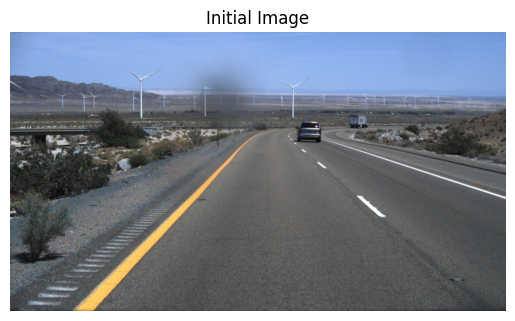

In [34]:
if loaded_image.image is not None:
    plt.imshow(loaded_image.image)
    plt.axis("off")
    plt.title("Initial Image")
    plt.show()

In [35]:
# We are basically sending a loaded sample with actual image tensor in the memory

response = model.predict(loaded_image)

In [36]:
prediction = response.json()

ModelOutput = ModelPrediction (
    
    sample=Sample(
            image=prediction['sample']['image'],
            image_path=prediction['sample']['image_path'],
            h_samples=prediction['sample']['h_samples'],
            lanes=prediction['sample']['lanes'],
            blur=prediction['sample']['blur'],
            lighting=prediction['sample']['lighting'],
            zoom=prediction['sample']['zoom'],
            rotation=prediction['sample']['rotation']
        ),
    
    lanes=prediction['lanes'],
        
    run_time=prediction['run_time']
    
)

In [37]:

experiment.store_prediction(ModelOutput)

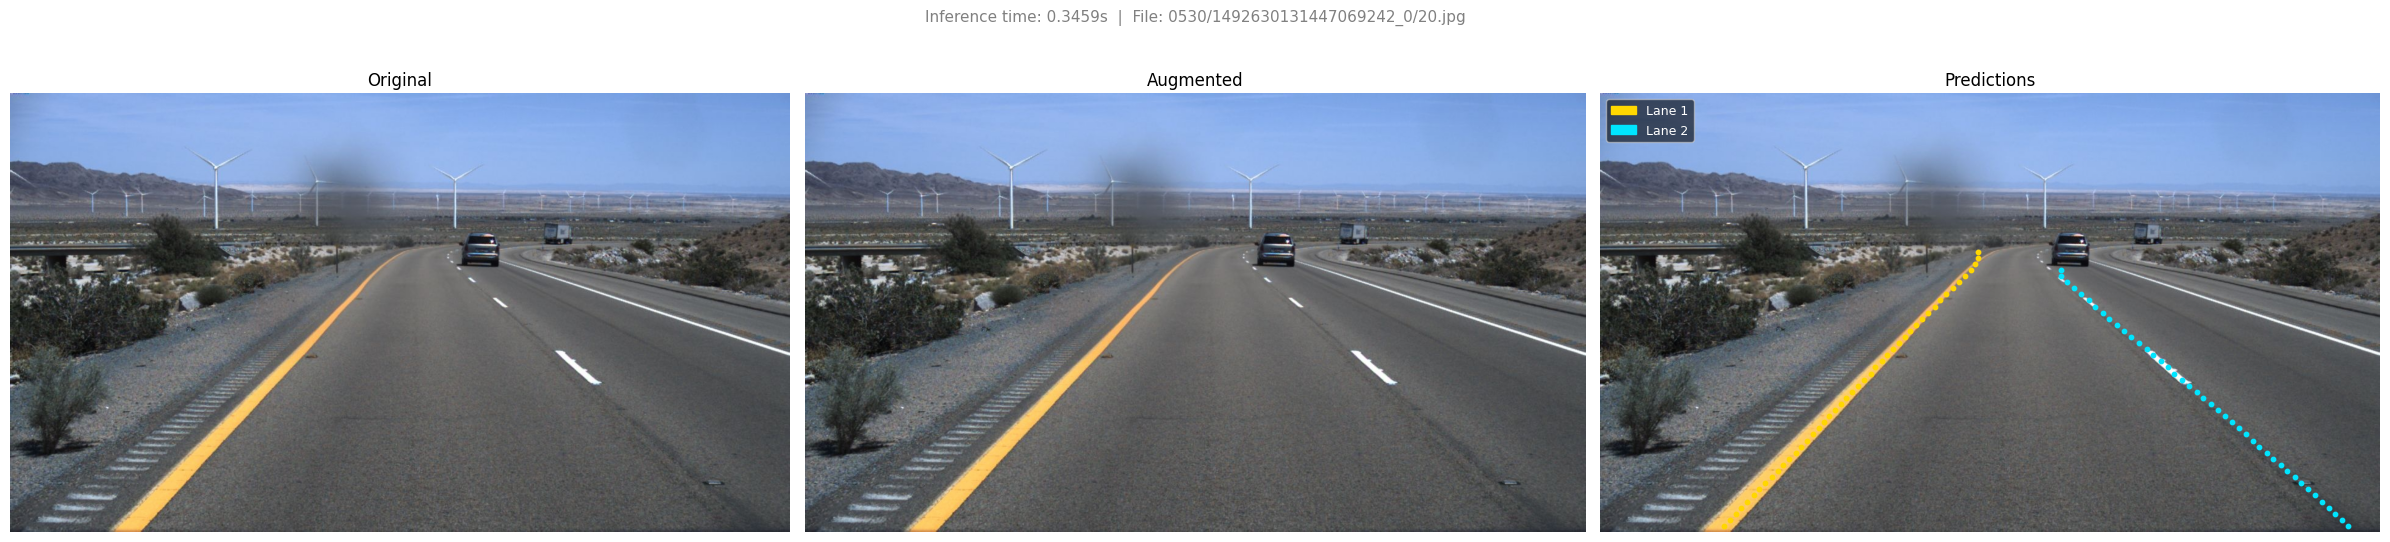

'../results/testing/2026_04_25__21_47_11_pipeline_testing_with_no_augmentation/inference/visualization_0000.png'

In [38]:
experiment.visualize_prediction(ModelOutput, show=True)